In [1]:
# import relevant libraries

import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

In [2]:
# load data from csv file into dataframe

cpc_data = pd.read_csv("cpc_data.csv", parse_dates=["Day"], index_col="Day")

# view first few rows

cpc_data.head()

,Avg. CPC,CTR,Clicks,Conv. rate,Conversions,Cost,Cost / conv.,Impr.,Status
Day,,,,,,,,,
2018-08-31,2.490563,16.894144,75,0.225225,1,1105.809783,1105.809783,7501,Active
2018-09-01,2.472161,5.976134,17,1.193317,5,1035.835572,207.167114,2504,Active
2018-09-02,2.508561,6.824919,3,0.107411,1,2335.470042,2335.470042,6354,Active
2018-09-03,2.548919,8.058366,99,2.723735,7,655.072103,93.581729,2071,Active
2018-09-04,2.414868,6.884937,93,1.464435,7,1154.306794,164.900970,3291,Active


In [3]:
# get some basic information

cpc_data.info()

<class 'pandas.core.frame.DataFrame'>
DatetimeIndex: 366 entries, 2018-08-31 to 2019-08-31
Data columns (total 9 columns):
 #   Column        Non-Null Count  Dtype  
---  ------        --------------  -----  
 0   Avg. CPC      366 non-null    float64
 1   CTR           366 non-null    float64
 2   Clicks        366 non-null    int64  
 3   Conv. rate    366 non-null    float64
 4   Conversions   366 non-null    int64  
 5   Cost          366 non-null    float64
 6   Cost / conv.  366 non-null    float64
 7   Impr.         366 non-null    int64  
 8   Status        366 non-null    object 
dtypes: float64(5), int64(3), object(1)
memory usage: 28.6+ KB


In [5]:
# resample the data by week and take the average

cpc_weekly = cpc_data["Cost"].resample('W').mean()

cpc_weekly.head()

Day
2018-09-02    1492.371799
2018-09-09    1073.762622
2018-09-16    1554.423832
2018-09-23    1322.445411
2018-09-30    1041.005947
Freq: W-SUN, Name: Cost, dtype: float64

In [6]:
# create rolling averages using a 7-day rolling window 

cpc_rolling_7d = cpc_data["Cost"].rolling(window=7, #set a rolling window of 7 days
                                          center=True # label each window at its midpoint
                                         ).mean()

cpc_rolling_7d.head()

Day
2018-08-31            NaN
2018-09-01            NaN
2018-09-02            NaN
2018-09-03    1248.123595
2018-09-04    1319.591703
Name: Cost, dtype: float64

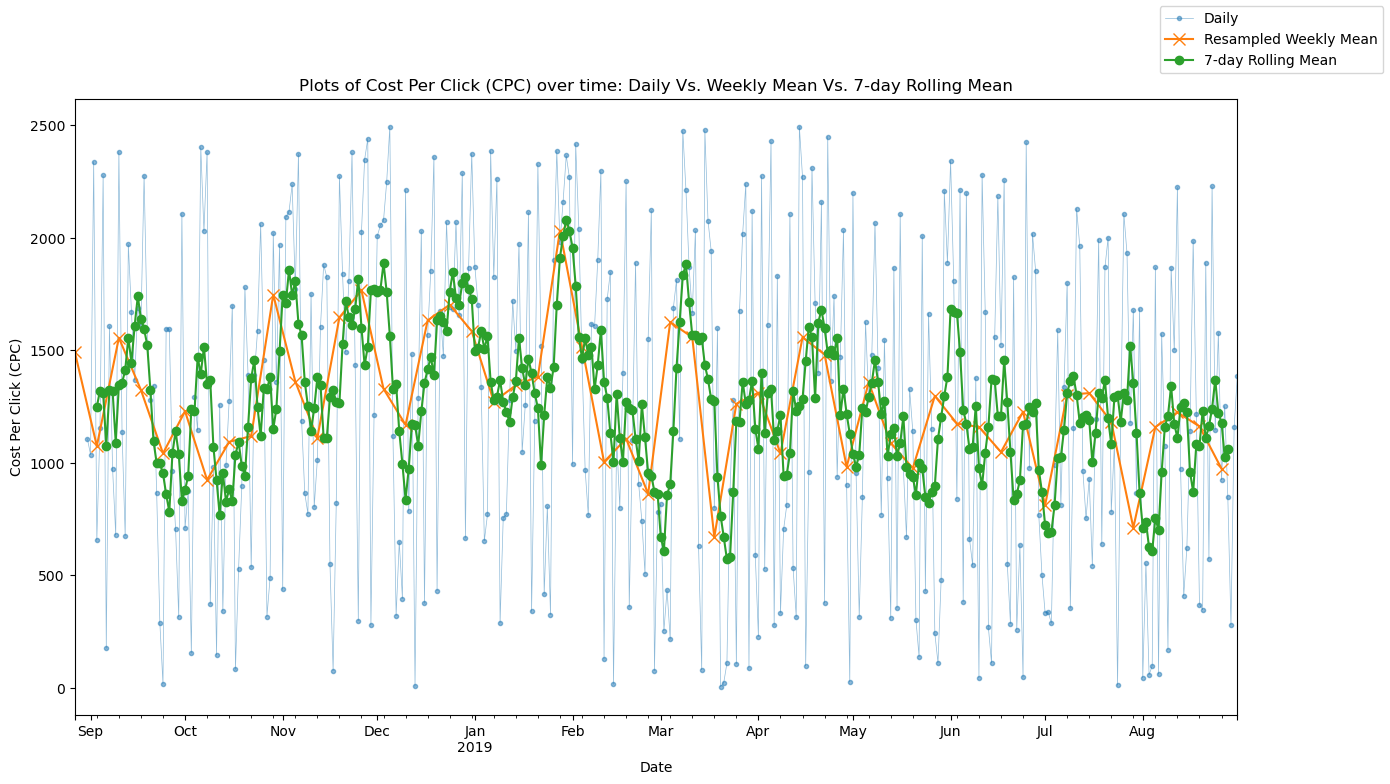

In [7]:
# create matplotlib figure

fig, axs = plt.subplots(1, 1, figsize=(15,5))

# create plot for daily

cpc_data["Cost"].plot(figsize=(15,8), 
                      alpha=0.5, 
                      marker=".", 
                      linestyle="-", 
                      linewidth=0.5, 
                      label="Daily"
                    )

# create plot for resampled weekly mean

cpc_weekly.plot(figsize=(15,8),
                marker="x",
                markersize=8, 
                linestyle="-",
                label="Resampled Weekly Mean"
               )

# create plot for 7-day rolling mean

cpc_rolling_7d.plot(figsize=(15,8),
                   marker="o",
                   linestyle="-",
                   label="7-day Rolling Mean"
                  )

# set x-axis label

axs.set_xlabel("Date")

# set y-axis label

axs.set_ylabel("Cost Per Click (CPC)")

# add legend

fig.legend()

# add title 

plt.title("Plots of Cost Per Click (CPC) over time: Daily Vs. Weekly Mean Vs. 7-day Rolling Mean")

# display the plots

plt.show() 